In [2]:
import gymnasium as gym
from gymnasium.vector import SyncVectorEnv
import icu_sepsis

import numpy as np
import matplotlib.pyplot as plt
import os
import re
import glob
import random
from itertools import product

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

env = gym.make('Sepsis/ICU-Sepsis-v2')

state, info = env.reset()
print('Initial state:', state)
print('Extra info:', info)

next_state, reward, terminated, truncated, info = env.step(0)
print('\nTaking action 0:')
print('Next state:', next_state)
print('Reward:', reward)
print('Terminated:', terminated)
print('Truncated:', truncated)

print("Actions and State Space:")

print("Action space:", env.action_space)
print("State space:", env.observation_space)

Initial state: 76
Extra info: {'admissible_actions': [0], 'state_vector': array([ 0.08974359, -0.46581197, -0.49590598,  0.62991453, -0.80353877,
       -0.34807798,  0.36774101,  1.34949168, -0.08798603,  0.3027486 ,
        0.47656618,  0.59906593,  0.15057277, -0.2295564 , -0.75933425,
       -0.49459061, -0.4628788 , -0.35127154, -0.51805173, -0.2874676 ,
        0.17636776,  0.02253388,  0.23831862, -0.22467781, -0.16572207,
        0.46334093, -0.16800551, -0.08709837,  0.32586352,  0.00883326,
       -0.06799694,  0.33240821,  1.03805436,  1.02052725, -0.05657031,
        0.17632821,  0.0564665 , -0.94864475, -0.59881284, -0.30528363,
       -0.30037556, -0.09712847, -0.15225767,  0.12131162, -2.9909082 ,
       -2.55840929, -1.86390726]), 'sofa_score': np.float64(7.466522678185745)}

Taking action 0:
Next state: 76
Reward: 0.0
Terminated: False
Truncated: False
Actions and State Space:
Action space: Discrete(25)
State space: Discrete(716)


In [3]:
# Policy network class
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)
        self.apply(init_weights_He)
        # self.apply(init_weights_xavier)

    # forward pass through ReLU (no softmax here)
    def forward(self, x):
        x = F.leaky_relu(self.fc1(x))
        x = F.leaky_relu(self.fc2(x))
        return self.fc3(x)  # return raw logits

    
# Critic Network for Actor-Critic agent (for V(s) estimates)
class CriticNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim):
        super(CriticNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 1)
        self.apply(init_weights_He)
    
    # forward pass through ReLU and linear layer
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)
    
def init_weights_He(layer):
    if hasattr(layer, 'weight') and layer.weight is not None:
        nn.init.kaiming_uniform_(layer.weight, mode='fan_in', nonlinearity='relu')
    if hasattr(layer, 'bias') and layer.bias is not None:
        # Initialize biases to zero instead of using Xavier
        nn.init.zeros_(layer.bias)

def init_weights_xavier(layer):
    if hasattr(layer, 'weight') and layer.weight is not None:
        nn.init.xavier_uniform_(layer.weight, gain=nn.init.calculate_gain('relu'))
    if hasattr(layer, 'bias') and layer.bias is not None:
        # Initialize biases to zero instead of using Xavier
        nn.init.zeros_(layer.bias)
      

# A2C Agent Class
class A2CAgent:
    def __init__(self, env_name, hidden_dim=128,
                 lr_actor=1e-3, lr_critic=1e-3,
                 entropy_c=0.005, value_c=0.5,
                 gamma=0.99, device='cpu'):
        # env
        self.env = gym.make(env_name)
        self.state_dim = self.env.observation_space.n
        self.action_dim = self.env.action_space.n
        self.gamma = gamma
        self.entropy_c = entropy_c
        self.value_c = value_c
        self.device = torch.device(device)

        # networks + optimizers
        self.policy_net = PolicyNetwork(self.state_dim, self.action_dim, hidden_dim).to(self.device)
        self.critic_net = CriticNetwork(self.state_dim, hidden_dim).to(self.device)
        self.policy_opt = optim.Adam(self.policy_net.parameters(), lr=lr_actor)
        self.critic_opt = optim.Adam(self.critic_net.parameters(), lr=lr_critic)

        # JIT compile for speed (PyTorch 2.0+)
        self.policy_net = torch.compile(self.policy_net)
        self.critic_net = torch.compile(self.critic_net)

    def train_one_episode(self):
        state, _ = self.env.reset()
        done = False
        total_r, length, inad = 0.0, 0, 0

        while not done:
            length += 1
            s = F.one_hot(torch.tensor(state), self.state_dim).float().unsqueeze(0).to(self.device)

            logits = self.policy_net(s)
            dist = Categorical(logits=logits)
            action = dist.sample()
            logp = dist.log_prob(action)
            ent = dist.entropy()
            value = self.critic_net(s)

            next_state, reward, term, trunc, info = self.env.step(action.item())
            done = term or trunc
            total_r += reward
            if info.get('inadmissible', False):
                inad += 1

            # bootstrap
            s2 = F.one_hot(torch.tensor(next_state), self.state_dim).float().unsqueeze(0).to(self.device)
            v2 = self.critic_net(s2).detach()

            adv = reward + self.gamma * v2 * (1 - int(done)) - value

            loss_actor = -(logp * adv.detach()) - self.entropy_c * ent
            loss_critic = self.value_c * adv.pow(2).mean()

            self.policy_opt.zero_grad()
            loss_actor.backward()
            self.policy_opt.step()

            self.critic_opt.zero_grad()
            loss_critic.backward()
            self.critic_opt.step()

            state = next_state

        return total_r, length, inad / length

    def save(self, ckpt_dir, tag, seed, ep=None):
            os.makedirs(ckpt_dir, exist_ok=True)
            if ep is not None:
                fa = f"{tag}_seed{seed}_ep{ep}_policy.pth"
                fc = f"{tag}_seed{seed}_ep{ep}_critic.pth"
            else:
                fa = f"{tag}_seed{seed}_final_policy.pth"
                fc = f"{tag}_seed{seed}_final_critic.pth"
            torch.save(self.policy_net.state_dict(), os.path.join(ckpt_dir, fa))
            torch.save(self.critic_net.state_dict(), os.path.join(ckpt_dir, fc))

    def load(self, ckpt_dir, tag, seed, ep):
        pa = os.path.join(ckpt_dir, f"{tag}_seed{seed}_ep{ep}_policy.pth")
        ca = os.path.join(ckpt_dir, f"{tag}_seed{seed}_ep{ep}_critic.pth")
        self.policy_net.load_state_dict(torch.load(pa, map_location=self.device))
        self.critic_net.load_state_dict(torch.load(ca, map_location=self.device))



In [5]:
# reproducibility
seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

env_name = 'Sepsis/ICU-Sepsis-v2'
agent = A2CAgent(
        env_name   = 'Sepsis/ICU-Sepsis-v2',
        hidden_dim = 256,
        lr_actor   = 0.025,
        lr_critic  = 0.025,
        entropy_c  = 0.25,
        value_c    = 0.3,
        gamma      = 1.0,
        device     = 'cpu'
    )

N_EPISODES = 500_000
returns, lengths, inad_freqs = [], [], []

for ep in tqdm(range(1, N_EPISODES+1), desc='A2C Test', unit='ep'):
    r, l, inad = agent.train_one_episode()
    returns.append(r)
    lengths.append(l)
    inad_freqs.append(inad)


A2C Test: 100%|██████████| 500000/500000 [4:43:24<00:00, 29.40ep/s]   


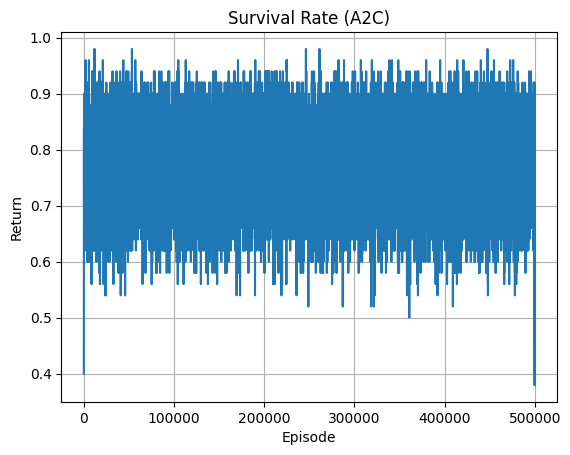

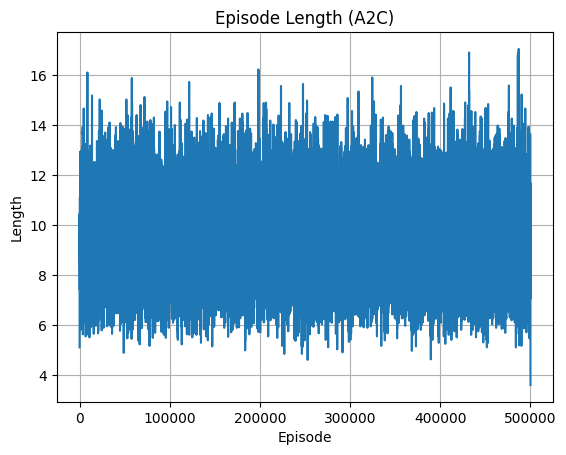

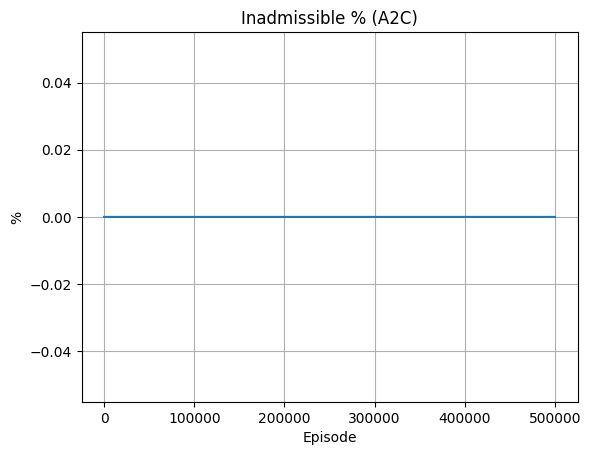

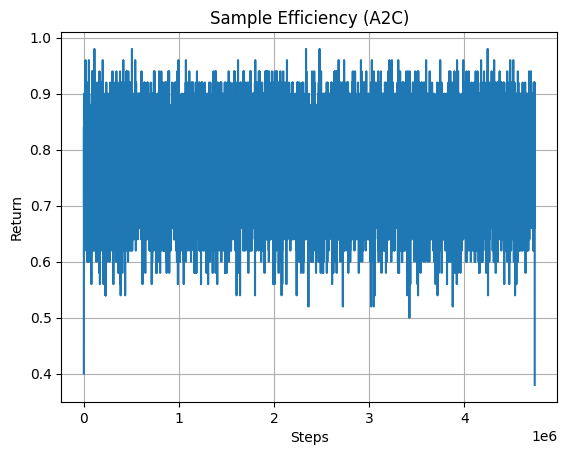

In [6]:
# smoothing helper
def smooth(x, w=50): return np.convolve(x, np.ones(w)/w, mode='same')

sr = smooth(np.array(returns))
sl = smooth(np.array(lengths))
si = smooth(np.array(inad_freqs))
cum_steps = np.cumsum(lengths)

plt.figure(); plt.plot(sr); plt.title('Survival Rate (A2C)'); plt.xlabel('Episode'); plt.ylabel('Return'); plt.grid(); plt.show()
plt.figure(); plt.plot(sl); plt.title('Episode Length (A2C)'); plt.xlabel('Episode'); plt.ylabel('Length'); plt.grid(); plt.show()
plt.figure(); plt.plot(si); plt.title('Inadmissible % (A2C)'); plt.xlabel('Episode'); plt.ylabel('%'); plt.grid(); plt.show()
plt.figure(); plt.plot(cum_steps, sr); plt.title('Sample Efficiency (A2C)'); plt.xlabel('Steps'); plt.ylabel('Return'); plt.grid(); plt.show()

In [4]:
base_dir = '/Users/nicksmits/Library/CloudStorage/OneDrive-Personal(2)/COMP 579/A2C'
seeds = range(3)

# small hyperparameter grid
hyper_grid = {
    'lr':  [5e-4, 1e-3],
    'entropy_c': [0.001, 0.005],
    'value_c':   [0.3, 0.5],
}

episodes = 300_000
checkpoint_interval = 100_000

for lr, ent_c, val_c in product(
        hyper_grid['lr'],
        hyper_grid['entropy_c'],
        hyper_grid['value_c']
    ):
    tag = f"A2C_lr{lr}_ent{ent_c}_val{val_c}"
    ckpt_dir = os.path.join(base_dir, tag)

    for seed in seeds:
        # reproducibility
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        # metric file paths
        f_ret  = os.path.join(ckpt_dir, f"{tag}_seed{seed}_returns.npy")
        f_len  = os.path.join(ckpt_dir, f"{tag}_seed{seed}_lengths.npy")
        f_inad = os.path.join(ckpt_dir, f"{tag}_seed{seed}_inad.npy")

        # resume existing metrics
        returns = list(np.load(f_ret))  if os.path.exists(f_ret)  else []
        lengths = list(np.load(f_len))  if os.path.exists(f_len)  else []
        inads   = list(np.load(f_inad)) if os.path.exists(f_inad) else []

        # find last checkpoint to resume
        start_ep = len(returns) + 1
        max_ep = 0
        if os.path.isdir(ckpt_dir):
            pat = re.compile(fr"{re.escape(tag)}_seed{seed}_ep(\d+)_policy\.pth")
            for fn in os.listdir(ckpt_dir):
                m = pat.match(fn)
                if m:
                    epn = int(m.group(1))
                    max_ep = max(max_ep, epn)
            if max_ep:
                start_ep = max_ep + 1

        # instantiate agent
        agent = A2CAgent(
            env_name   = 'Sepsis/ICU-Sepsis-v2',
            hidden_dim = 128,
            lr_actor   = lr,
            lr_critic  = lr,
            entropy_c  = ent_c,
            value_c    = val_c,
            gamma      = 0.99,
            device     = 'cpu'
        )
        # load weights if resuming
        if max_ep:
            agent.load(ckpt_dir, tag, seed, max_ep)

        # training loop
        pbar = tqdm(range(start_ep, episodes+1),
                    desc=f"{tag} | seed{seed}", unit='ep')
        for ep in pbar:
            r, length, inad_freq = agent.train_one_episode()
            returns.append(r)
            lengths.append(length)
            inads.append(inad_freq)
            pbar.set_postfix({
                "r":      f"{r:.2f}",
                "len":    length,
                "inad%":  f"{inad_freq:.2%}"
            })

            # checkpoint & save metrics
            if ep % checkpoint_interval == 0:
                agent.save(ckpt_dir, tag, seed, ep)
                np.save(f_ret,  np.array(returns))
                np.save(f_len,  np.array(lengths))
                np.save(f_inad, np.array(inads))

        # final save after all episodes
        agent.save(ckpt_dir, tag, seed)
        np.save(f_ret,  np.array(returns))
        np.save(f_len,  np.array(lengths))
        np.save(f_inad, np.array(inads))

/var/folders/bd/5y876_fs4td3chn71x256drh0000gn/T/ipykernel_51088/792305967.py:130: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.policy_net.load_state_dict(torch.load(p

KeyboardInterrupt: 


Looking in: /Users/nicksmits/Library/CloudStorage/OneDrive-Personal(2)/COMP 579/A2C/A2C_lr0.0005_ent0.001_val0.3
  contains: ['A2C_lr0.0005_ent0.001_val0.3_seed0_ep300000_critic.pth', 'A2C_lr0.0005_ent0.001_val0.3_seed0_ep300000_policy.pth', 'A2C_lr0.0005_ent0.001_val0.3_seed0_final_critic.pth', 'A2C_lr0.0005_ent0.001_val0.3_seed0_final_policy.pth', 'A2C_lr0.0005_ent0.001_val0.3_seed0_inad.npy', 'A2C_lr0.0005_ent0.001_val0.3_seed0_lengths.npy', 'A2C_lr0.0005_ent0.001_val0.3_seed0_returns.npy', 'A2C_lr0.0005_ent0.001_val0.3_seed1_ep300000_critic.pth', 'A2C_lr0.0005_ent0.001_val0.3_seed1_ep300000_policy.pth', 'A2C_lr0.0005_ent0.001_val0.3_seed1_final_critic.pth', 'A2C_lr0.0005_ent0.001_val0.3_seed1_final_policy.pth', 'A2C_lr0.0005_ent0.001_val0.3_seed1_inad.npy', 'A2C_lr0.0005_ent0.001_val0.3_seed1_lengths.npy', 'A2C_lr0.0005_ent0.001_val0.3_seed1_returns.npy', 'A2C_lr0.0005_ent0.001_val0.3_seed2_ep300000_critic.pth', 'A2C_lr0.0005_ent0.001_val0.3_seed2_ep300000_policy.pth', 'A2C_lr0.00

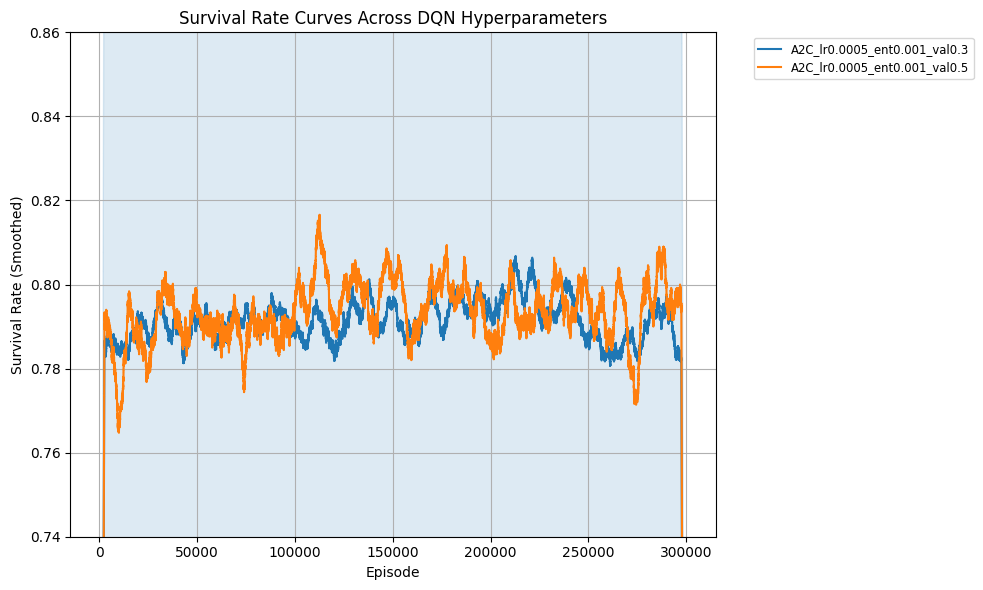

In [3]:
from pathlib import Path
# Configuration (reuse from before)
base_dir = "/Users/nicksmits/Library/CloudStorage/OneDrive-Personal(2)/COMP 579/A2C"
base = Path(base_dir)
seeds = range(3)

hyper_grid = {
    'lr':  [5e-4, 1e-3],
    'entropy_c': [0.001, 0.005],
    'value_c':   [0.3, 0.5],
}

window = 5000

def smooth(x, w=window):
    return np.convolve(x, np.ones(w)/w, mode='same')


# Gather all tags
tags = []
for lr, ent_c, val_c in product(
        hyper_grid['lr'],
        hyper_grid['entropy_c'],
        hyper_grid['value_c']
    ):
    tags.append(f"A2C_lr{lr}_ent{ent_c}_val{val_c}")

for tag in tags:
    ckpt_dir = base / tag
    print(f"\nLooking in: {ckpt_dir}")
    if not ckpt_dir.exists():
        print("  → directory does NOT exist!")
        continue

    # list everything in it
    all_files = sorted([p.name for p in ckpt_dir.iterdir()])
    print("  contains:", all_files)

    # now look for your *.npy
    pattern = str(ckpt_dir / f"{tag}_seed*_returns.npy")
    matches = glob.glob(pattern)
    print("  matched by glob:", [Path(m).name for m in matches])

# Prepare plot
plt.figure(figsize=(10,6))
colors = plt.cm.tab10(np.linspace(0,1,len(tags)))

for color, tag in zip(colors, tags):
    ckpt_dir = os.path.join(base_dir, tag)
    # Load returns for all seeds
    rets = []
    for seed in seeds:
        f_ret = os.path.join(ckpt_dir, f"{tag}_seed{seed}_returns.npy")
        print(f_ret)
        if os.path.exists(f_ret):
            rets.append(np.load(f_ret))
    if not rets:
        continue

    rets = np.stack(rets)          # shape (n_seeds, episodes)
    mean_r = rets.mean(axis=0)     # [episodes]
    std_r  = rets.std(axis=0)

    # smooth mean only
    sr = smooth(mean_r)
    std_r = smooth(std_r)
    sstd = std_r / np.sqrt(len(seeds))
    # clamp shading bounds [0,1]
    lower = np.maximum(sr - sstd, 0.0)
    upper = np.minimum(sr + sstd, 1.0)

    episodes = len(sr)
    x = np.arange(episodes)

    # plot
    plt.plot(x, sr, color=color, label=tag)
    plt.fill_between(x, lower, upper, color=color, alpha=0.15)

plt.title("Survival Rate Curves Across DQN Hyperparameters")
plt.xlabel("Episode")
plt.ylabel("Survival Rate (Smoothed)")
plt.ylim(0.74,0.86)
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

8

Looking in: /Users/nicksmits/Library/CloudStorage/OneDrive-Personal(2)/COMP 579/A2C/A2C_lr0.0005_ent0.001_val0.3
  contains: ['A2C_lr0.0005_ent0.001_val0.3_seed0_ep300000_critic.pth', 'A2C_lr0.0005_ent0.001_val0.3_seed0_ep300000_policy.pth', 'A2C_lr0.0005_ent0.001_val0.3_seed0_final_critic.pth', 'A2C_lr0.0005_ent0.001_val0.3_seed0_final_policy.pth', 'A2C_lr0.0005_ent0.001_val0.3_seed0_inad.npy', 'A2C_lr0.0005_ent0.001_val0.3_seed0_lengths.npy', 'A2C_lr0.0005_ent0.001_val0.3_seed0_returns.npy', 'A2C_lr0.0005_ent0.001_val0.3_seed1_ep300000_critic.pth', 'A2C_lr0.0005_ent0.001_val0.3_seed1_ep300000_policy.pth', 'A2C_lr0.0005_ent0.001_val0.3_seed1_final_critic.pth', 'A2C_lr0.0005_ent0.001_val0.3_seed1_final_policy.pth', 'A2C_lr0.0005_ent0.001_val0.3_seed1_inad.npy', 'A2C_lr0.0005_ent0.001_val0.3_seed1_lengths.npy', 'A2C_lr0.0005_ent0.001_val0.3_seed1_returns.npy', 'A2C_lr0.0005_ent0.001_val0.3_seed2_ep300000_critic.pth', 'A2C_lr0.0005_ent0.001_val0.3_seed2_ep300000_policy.pth', 'A2C_lr0.

/var/folders/bd/5y876_fs4td3chn71x256drh0000gn/T/ipykernel_26324/1066382606.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')


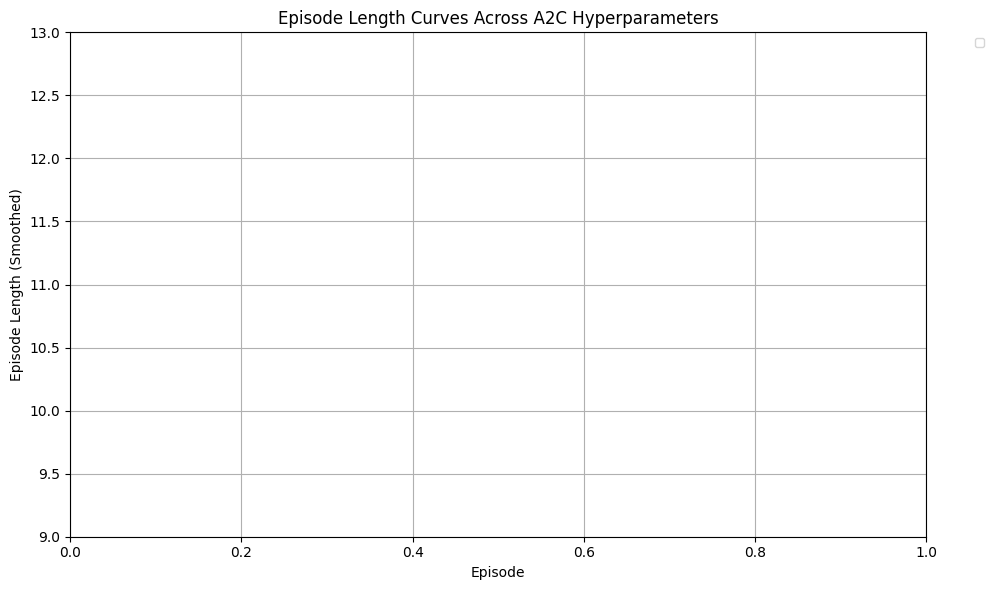

In [6]:
# Configuration (reuse from before)
base_dir = "/Users/nicksmits/Library/CloudStorage/OneDrive-Personal(2)/COMP 579/A2C"
base = Path(base_dir)
seeds = range(3)

window = 5000

def smooth(x, w=window):
    return np.convolve(x, np.ones(w)/w, mode='same')

hyper_grid = {
    'lr':  [5e-4, 1e-3],
    'entropy_c': [0.001, 0.005],
    'value_c':   [0.3, 0.5],
}

# Gather all tags
tags = []
for lr, ent_c, val_c in product(
        hyper_grid['lr'],
        hyper_grid['entropy_c'],
        hyper_grid['value_c']
    ):
    tags.append(f"A2C_lr{lr}_ent{ent_c}_val{val_c}")

print(len(tags))   
for tag in tags:
    ckpt_dir = base / tag
    print(f"\nLooking in: {ckpt_dir}")
    if not ckpt_dir.exists():
        print("  → directory does NOT exist!")
        continue

    # list everything in it
    all_files = sorted([p.name for p in ckpt_dir.iterdir()])
    print("  contains:", all_files)

    # now look for your *.npy
    pattern = str(ckpt_dir / f"{tag}_seed*_returns.npy")
    matches = glob.glob(pattern)
    print("  matched by glob:", [Path(m).name for m in matches])

# Prepare plot
plt.figure(figsize=(10,6))
colors = plt.cm.tab10(np.linspace(0,1,len(tags)))

for color, tag in zip(colors, tags):
    ckpt_dir = os.path.join(base_dir, tag)
    # Load returns for all seeds
    lens = []
    for seed in seeds:
        f_len = os.path.join(ckpt_dir, f"{tag}_seed{seed}_lengths.npy")
        print(f_len)
        if os.path.exists(f_ret):
            lens.append(np.load(f_len))
    if not lens:
        continue

    lens = np.stack(lens)          # shape (n_seeds, episodes)
    mean_l = lens.mean(axis=0)     # [episodes]
    std_l  = lens.std(axis=0)

    # smooth mean only
    sl = smooth(mean_l)
    std_l = smooth(std_l)
    sstd = std_l / np.sqrt(len(seeds))

    episodes = len(sl)
    x = np.arange(episodes)

    lower = sl - sstd
    upper = sl + sstd

    # plot
    plt.plot(x, sl, color=color, label=tag)
    plt.fill_between(x, lower, upper, color=color, alpha=0.15)

plt.title("Episode Length Curves Across A2C Hyperparameters")
plt.xlabel("Episode")
plt.ylabel("Episode Length (Smoothed)")
plt.ylim(9, 13)
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()